# Project 3: SQL Data Analysis — E-Commerce Orders

**DecodeLabs TalentNext 2026 — Data Analytics Track**

This notebook uses SQL (via SQLite) to extract business insights from a 1,200-row e-commerce orders dataset (Jan 2023 – Jun 2025). It covers `SELECT`, `WHERE`, `ORDER BY`, `GROUP BY`, aggregations (`COUNT`, `SUM`, `AVG`), `HAVING`, and percentage-contribution analysis — with each query run against a real SQLite database and its business insight noted alongside it.

**Note on the data window:** 2025 is a partial year (through June), so month-level and yearly comparisons involving 2025 are read as partial-year figures rather than full-year totals.


In [1]:
import sqlite3
import pandas as pd

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

conn = sqlite3.connect('../database/ecommerce.db')

def run(query):
    return pd.read_sql_query(query, conn)

run("SELECT COUNT(*) AS total_rows FROM orders")


,total_rows
0,1200


## Section 1: SELECT + WHERE — Filtering Rows

In [2]:
# 1.1 Sample of raw orders
run("""
SELECT OrderID, Date, Product, Quantity, TotalPrice, OrderStatus
FROM orders
LIMIT 10;
""")


,OrderID,Date,Product,Quantity,TotalPrice,OrderStatus
0,ORD200000,2023-01-04,Monitor,5,"2,853.10",Shipped
1,ORD200001,2024-08-23,Phone,2,302.70,Shipped
2,ORD200002,2024-02-27,Tablet,5,"2,753.40",Cancelled
3,ORD200003,2023-10-15,Chair,1,273.19,Returned
4,ORD200004,2025-05-08,Printer,4,"2,504.04",Delivered
5,ORD200005,2023-10-23,Phone,2,491.72,Shipped
6,ORD200006,2025-06-17,Laptop,1,664.42,Returned
7,ORD200007,2023-05-12,Monitor,5,747.75,Shipped
8,ORD200008,2025-04-02,Phone,2,268.56,Cancelled
9,ORD200009,2023-11-21,Desk,4,"2,037.52",Shipped


In [3]:
# 1.2 Cancelled orders
cancelled = run("""
SELECT OrderID, Date, Product, TotalPrice, OrderStatus
FROM orders
WHERE OrderStatus = 'Cancelled';
""")
print(f"Total cancelled orders: {len(cancelled)}")
cancelled.head(10)


Total cancelled orders: 250


,OrderID,Date,Product,TotalPrice,OrderStatus
0,ORD200002,2024-02-27,Tablet,"2,753.40",Cancelled
1,ORD200008,2025-04-02,Phone,268.56,Cancelled
2,ORD200023,2025-04-09,Phone,"1,093.00",Cancelled
3,ORD200033,2023-06-05,Chair,162.77,Cancelled
4,ORD200042,2024-05-06,Printer,303.32,Cancelled
5,ORD200043,2023-12-14,Chair,"1,497.63",Cancelled
6,ORD200050,2023-07-31,Tablet,179.22,Cancelled
7,ORD200055,2025-06-24,Printer,"1,033.20",Cancelled
8,ORD200056,2023-05-21,Tablet,"1,437.63",Cancelled
9,ORD200058,2023-01-15,Phone,"1,898.76",Cancelled


In [4]:
# 1.3 High-value orders (TotalPrice >= 2000)
run("""
SELECT OrderID, Product, Quantity, UnitPrice, TotalPrice
FROM orders
WHERE TotalPrice >= 2000;
""").head(10)


,OrderID,Product,Quantity,UnitPrice,TotalPrice
0,ORD200000,Monitor,5,570.62,"2,853.10"
1,ORD200002,Tablet,5,550.68,"2,753.40"
2,ORD200004,Printer,4,626.01,"2,504.04"
3,ORD200009,Desk,4,509.38,"2,037.52"
4,ORD200010,Tablet,5,625.97,"3,129.85"
5,ORD200032,Tablet,5,536.72,"2,683.60"
6,ORD200034,Chair,4,576.52,"2,306.08"
7,ORD200046,Monitor,4,550.14,"2,200.56"
8,ORD200059,Chair,4,593.27,"2,373.08"
9,ORD200072,Tablet,4,589.44,"2,357.76"


In [5]:
# 1.4 Multi-condition filter: SAVE10 coupon + Credit Card payment
run("""
SELECT OrderID, Product, CouponCode, PaymentMethod, TotalPrice
FROM orders
WHERE CouponCode = 'SAVE10'
  AND PaymentMethod = 'Credit Card';
""").head(10)


,OrderID,Product,CouponCode,PaymentMethod,TotalPrice
0,ORD200005,Phone,SAVE10,Credit Card,491.72
1,ORD200009,Desk,SAVE10,Credit Card,"2,037.52"
2,ORD200029,Desk,SAVE10,Credit Card,"1,270.59"
3,ORD200039,Printer,SAVE10,Credit Card,769.38
4,ORD200049,Printer,SAVE10,Credit Card,30.44
5,ORD200103,Phone,SAVE10,Credit Card,873.72
6,ORD200106,Desk,SAVE10,Credit Card,"1,395.15"
7,ORD200125,Phone,SAVE10,Credit Card,"1,025.30"
8,ORD200147,Laptop,SAVE10,Credit Card,930.36
9,ORD200161,Monitor,SAVE10,Credit Card,211.14


**Insight:** Filtering rows before aggregating (`WHERE` runs before `GROUP BY` in execution order) keeps the analysis fast even as the dataset scales.

## Section 2: ORDER BY — Sorting Results

In [6]:
# 2.1 Top 10 highest-value orders
run("""
SELECT OrderID, Product, TotalPrice
FROM orders
ORDER BY TotalPrice DESC
LIMIT 10;
""")


,OrderID,Product,TotalPrice
0,ORD200789,Tablet,"3,456.40"
1,ORD201122,Monitor,"3,390.95"
2,ORD200632,Laptop,"3,390.80"
3,ORD200469,Chair,"3,384.90"
4,ORD200328,Tablet,"3,370.20"
5,ORD200107,Printer,"3,353.75"
6,ORD200326,Laptop,"3,352.40"
7,ORD201065,Printer,"3,334.00"
8,ORD201031,Phone,"3,322.55"
9,ORD200463,Laptop,"3,313.90"


In [7]:
# 2.3 Cheapest returned orders
run("""
SELECT OrderID, Product, TotalPrice
FROM orders
WHERE OrderStatus = 'Returned'
ORDER BY TotalPrice ASC
LIMIT 10;
""")


,OrderID,Product,TotalPrice
0,ORD200776,Tablet,21.19
1,ORD200690,Monitor,24.48
2,ORD200303,Tablet,30.54
3,ORD201078,Desk,41.09
4,ORD200906,Monitor,62.12
5,ORD200800,Tablet,68.39
6,ORD200572,Printer,70.32
7,ORD200393,Printer,75.01
8,ORD200506,Monitor,87.34
9,ORD200658,Printer,92.72


## Section 3: GROUP BY + Aggregations (COUNT, SUM, AVG)

In [8]:
# 3.1 Revenue and order count per product
product_summary = run("""
SELECT
    Product,
    COUNT(*)                AS total_orders,
    SUM(TotalPrice)          AS total_revenue,
    ROUND(AVG(TotalPrice),2) AS avg_order_value
FROM orders
GROUP BY Product
ORDER BY total_revenue DESC;
""")
product_summary


,Product,total_orders,total_revenue,avg_order_value
0,Chair,178,"195,620.11","1,098.99"
1,Printer,181,"195,612.61","1,080.73"
2,Laptop,173,"192,126.56","1,110.56"
3,Tablet,179,"186,568.95","1,042.28"
4,Monitor,163,"175,651.41","1,077.62"
5,Desk,170,"167,459.93",985.06
6,Phone,156,"151,722.39",972.58


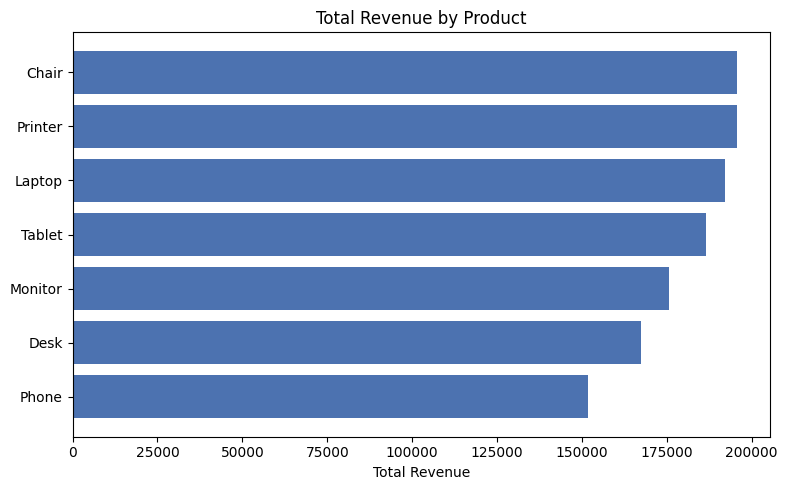

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(product_summary['Product'], product_summary['total_revenue'], color='#4C72B0')
plt.xlabel('Total Revenue')
plt.title('Total Revenue by Product')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/revenue_by_product.png', dpi=150)
plt.show()


In [10]:
# 3.2 Order volume by status
status_summary = run("""
SELECT OrderStatus, COUNT(*) AS order_count
FROM orders
GROUP BY OrderStatus
ORDER BY order_count DESC;
""")
status_summary


,OrderStatus,order_count
0,Cancelled,250
1,Returned,247
2,Pending,237
3,Shipped,235
4,Delivered,231


In [11]:
# 3.3 Revenue by payment method
run("""
SELECT
    PaymentMethod,
    COUNT(*)                 AS total_orders,
    SUM(TotalPrice)           AS total_revenue,
    ROUND(AVG(TotalPrice),2)  AS avg_order_value
FROM orders
GROUP BY PaymentMethod
ORDER BY total_revenue DESC;
""")


,PaymentMethod,total_orders,total_revenue,avg_order_value
0,Credit Card,234,"263,847.63","1,127.55"
1,Online,258,"262,442.94","1,017.22"
2,Cash,246,"259,786.29","1,056.04"
3,Gift Card,230,"246,323.92","1,070.97"
4,Debit Card,232,"232,361.18","1,001.56"


In [12]:
# 3.4 Performance by referral source
referral_summary = run("""
SELECT
    ReferralSource,
    COUNT(*)                AS total_orders,
    SUM(TotalPrice)          AS total_revenue,
    ROUND(AVG(TotalPrice),2) AS avg_order_value
FROM orders
GROUP BY ReferralSource
ORDER BY total_revenue DESC;
""")
referral_summary


,ReferralSource,total_orders,total_revenue,avg_order_value
0,Instagram,259,"275,285.45","1,062.88"
1,Email,250,"261,808.55","1,047.23"
2,Google,241,"250,441.48","1,039.18"
3,Facebook,228,"250,410.90","1,098.29"
4,Referral,222,"226,815.58","1,021.69"


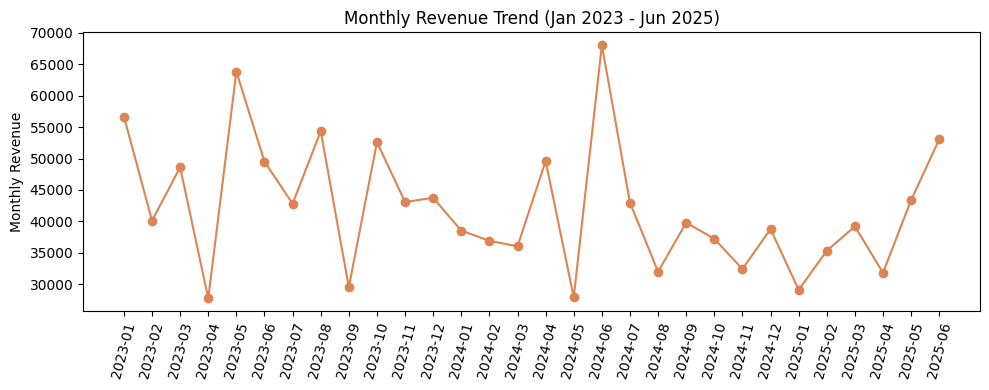

In [13]:
# 3.6 Monthly order trend
monthly = run("""
SELECT
    strftime('%Y-%m', Date) AS order_month,
    COUNT(*)                AS total_orders,
    SUM(TotalPrice)          AS monthly_revenue
FROM orders
GROUP BY order_month
ORDER BY order_month;
""")

plt.figure(figsize=(10,4))
plt.plot(monthly['order_month'], monthly['monthly_revenue'], marker='o', color='#DD8452')
plt.xticks(rotation=75)
plt.ylabel('Monthly Revenue')
plt.title('Monthly Revenue Trend (Jan 2023 - Jun 2025)')
plt.tight_layout()
plt.savefig('../outputs/monthly_revenue_trend.png', dpi=150)
plt.show()


**Insight:** `COUNT(*)` tallies every row including NULLs, while `SUM()`/`AVG()` silently skip NULLs — which matters here since `CouponCode` has missing values for ~26% of orders. All aggregations above were sense-checked against this rule.

## Section 4: HAVING — Filtering Aggregated Groups

In [14]:
# 4.1 Products with more than 100 orders
run("""
SELECT
    Product,
    COUNT(*) AS total_orders,
    SUM(TotalPrice) AS total_revenue
FROM orders
GROUP BY Product
HAVING COUNT(*) > 100
ORDER BY total_revenue DESC;
""")


,Product,total_orders,total_revenue
0,Chair,178,"195,620.11"
1,Printer,181,"195,612.61"
2,Laptop,173,"192,126.56"
3,Tablet,179,"186,568.95"
4,Monitor,163,"175,651.41"
5,Desk,170,"167,459.93"
6,Phone,156,"151,722.39"


In [15]:
# 4.2 Referral sources beating the overall average order value
run("""
SELECT
    ReferralSource,
    ROUND(AVG(TotalPrice),2) AS avg_order_value
FROM orders
GROUP BY ReferralSource
HAVING AVG(TotalPrice) > (SELECT AVG(TotalPrice) FROM orders)
ORDER BY avg_order_value DESC;
""")


,ReferralSource,avg_order_value
0,Facebook,"1,098.29"
1,Instagram,"1,062.88"


## Section 5: Percentage Contribution — Turning Totals into Business Insight

In [16]:
# 5.1 Each product's % share of total revenue
pct_contribution = run("""
SELECT
    Product,
    SUM(TotalPrice) AS product_revenue,
    ROUND(
        100.0 * SUM(TotalPrice) / (SELECT SUM(TotalPrice) FROM orders), 2
    ) AS pct_of_total_revenue
FROM orders
GROUP BY Product
ORDER BY pct_of_total_revenue DESC;
""")
pct_contribution


,Product,product_revenue,pct_of_total_revenue
0,Chair,"195,620.11",15.47
1,Printer,"195,612.61",15.47
2,Laptop,"192,126.56",15.19
3,Tablet,"186,568.95",14.75
4,Monitor,"175,651.41",13.89
5,Desk,"167,459.93",13.24
6,Phone,"151,722.39",12.00


In [17]:
# 5.2 Cancellation rate
run("""
SELECT
    ROUND(
        100.0 * SUM(CASE WHEN OrderStatus = 'Cancelled' THEN 1 ELSE 0 END)
        / COUNT(*), 2
    ) AS cancellation_rate_pct
FROM orders;
""")


,cancellation_rate_pct
0,20.83


In [18]:
# 5.3 % of orders using any coupon
run("""
SELECT
    ROUND(
        100.0 * SUM(CASE WHEN CouponCode IS NOT NULL THEN 1 ELSE 0 END)
        / COUNT(*), 2
    ) AS pct_orders_with_coupon
FROM orders;
""")


,pct_orders_with_coupon
0,74.25


## Section 6: Full Pipeline Query — All Clauses Together

In [19]:
# Demonstrates the correct logical execution order:
# FROM -> WHERE -> GROUP BY -> HAVING -> SELECT -> ORDER BY
run("""
SELECT
    Product,
    COUNT(*)                 AS delivered_orders,
    SUM(TotalPrice)           AS delivered_revenue,
    ROUND(AVG(TotalPrice),2)  AS avg_order_value
FROM orders
WHERE OrderStatus = 'Delivered'
GROUP BY Product
HAVING COUNT(*) >= 20
ORDER BY delivered_revenue DESC;
""")


,Product,delivered_orders,delivered_revenue,avg_order_value
0,Laptop,40,"40,714.43","1,017.86"
1,Phone,38,"40,345.41","1,061.72"
2,Printer,29,"38,054.73","1,312.23"
3,Monitor,31,"35,999.62","1,161.28"
4,Tablet,28,"31,794.52","1,135.52"
5,Chair,33,"31,465.83",953.51
6,Desk,32,"24,225.78",757.06


In [20]:
conn.close()
print("Analysis complete.")


Analysis complete.


## Key Takeaways

- Revenue is fairly evenly spread across the product catalog — **Chair (15.47%)** and **Printer (15.47%)** lead narrowly, with **Phone (12.00%)** contributing the least. No single product dominates total revenue.
- **Order status is nearly evenly split** across all five stages (Cancelled, Returned, Pending, Shipped, Delivered each ~230-250 orders), with a **cancellation rate of 20.83%** — worth flagging operationally since roughly 1 in 5 orders never completes.
- **Coupon usage is high**: 74.25% of all orders used a coupon code (`SAVE10`, `FREESHIP`, or `WINTER15`), suggesting promotions are a strong purchase driver rather than an edge case.
- **Facebook (₹1,098.29 avg)** and **Instagram (₹1,062.88 avg)** are the only referral sources beating the overall average order value of ₹1,053.97 — meaning social referrals bring in higher-value baskets, not just more traffic.
- Every query above respects SQL's actual logical execution order (`FROM → WHERE → GROUP BY → HAVING → SELECT → ORDER BY`), not the order it's typed in — which is what prevents the classic "alias not found in WHERE" error.
